# Does host vocabulary start uptake or grow it? — K1 / K3 / size-correct inference

This notebook is a runnable demo of the evaluation artifact **art_bA9y1v9g9mM_** (label: *POST-CONFIRMATION EXPLORATORY*).
The artifact takes the confirmed **D2 host-entry effect**, where more host-field vocabulary at entry (`A_cont`) goes with more newcomer uptake (`Y_strict`), and asks three follow-up questions:

* **K1 (which margin).** Does host vocabulary make uptake *start*? That is the **extensive** margin, `1[Y_strict >= 1]`, fitted with an LPM, an FE-logit and a log-link PPML. Or does it make uptake *grow* once it has started? That is the **intensive** margin, a PPML on the `Y >= 1` subsample. A log-link two-part decomposition with a concept-cluster bootstrap gives the extensive share.
* **K3 (field boundary).** Does the effect differ across the origin fields Physics/Astro, CS and other? This is a Wald equality test plus a label-permutation p.
* **INFERENCE fix.** Is the effect size-robust? The notebook runs a within-concept randomization-t (the headline), a Freedman-Lane permutation and a Webb wild cluster score bootstrap next to CRV1.

The original `eval.py` is only an orchestrator. It runs `k/k_freeze.py`, `k/k_run.py`, `audit/*.py` and `k/report.py` as subprocesses. All of the statistics live in **`k/k_run.py`** and **`k/k_lib.py`**, which import the vendored D2 modules `d2/src/ppml.py` and `d2/src/models.py`. This notebook inlines those files cell by cell, with the code kept as it was. There are four changes:
1. The data comes from `mini_demo_data.json` instead of parquet files.
2. The draw counts are config variables.
3. The `ProcessPoolExecutor(spawn)` is replaced with an in-process serial pool, because functions defined in a notebook cannot be pickled into spawned workers. The seeds are unchanged, so the numbers are unchanged.
4. The frozen-spec hash check and the RLIMIT memory caps are skipped.

**Demo data:** the **held-out fold** of the event table. It has 93 concepts (one example per concept) and 1,100 host-entry events. At full draw counts the held-out K1 and INFERENCE numbers reproduce the original run exactly: K1a-LPM +7.29 pp/SD, co-primary IRR/SD 1.187, randomization-t p 0.023. The original K3 pools the screen and held-out folds (214 concepts), so K3 here runs on the held-out fold alone and is illustrative only.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
This is the union of the original import blocks from `eval.py`, `k/k_lib.py`, `k/k_run.py` and the vendored `ppml.py` / `models.py`. As in `k_lib.py`, BLAS is pinned to one thread before numpy loads. Three imports are added for the notebook: `matplotlib` for the figure, `SimpleNamespace`, which lets the inlined modules keep their `K.` / `ppml.` / `models.` call sites, and `Future` for the serial pool.

In [2]:
from __future__ import annotations

import os
for _v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):  # one BLAS thread per worker process
    os.environ[_v] = "1"

import argparse
import hashlib
import json
import math
import multiprocessing as mp
import resource
import subprocess
import sys
import time
import warnings
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy import sparse, stats
from scipy.sparse.linalg import splu

# --- notebook additions
from concurrent.futures import Future
from types import SimpleNamespace
import matplotlib.pyplot as plt

## Data loading
The loader tries the GitHub copy of `mini_demo_data.json` first and falls back to a local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_desxWCcMY1R1/round-5/evaluation-6/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print(f"examples (concepts): {data['metadata']['n_examples']}, events: {data['metadata']['n_events']}")
print("frozen spec sha256:", data["metadata"]["spec_sha256"])

Held-out fold of the D2 host-entry event table (main arm, kw5, MAIN population), one example per concept with all its host-entry events. Used by the K1/K3/INFERENCE evaluation of the confirmed D2 effect (A_cont -> newcomer uptake Y_strict).
examples (concepts): 93, events: 1100
frozen spec sha256: 2435f909758bfab445fc28adab7b99efb5e4eed44a9f0e9b7377c1a470ddbbd5


## Configuration
These are all the tunable parameters. The original counts come from the frozen spec `k13_spec.json`: 1,000 cluster-bootstrap draws, 2,000 K3 label permutations, 2,000 randomization / Freedman-Lane draws and 9,999 Webb wild-bootstrap draws. The draws are cheap on the 93-concept held-out fold, so the **defaults are the original counts**. The whole notebook takes about 4 minutes, including the installs. For a quick look, set them to e.g. 20 / 20 / 20 / 999, which takes about 5 s of compute. Every draw is seeded from its draw index, so at the original counts the held-out K1 bootstrap CIs and all INFERENCE p-values reproduce the original run exactly.

In [5]:
# ---- draw counts (original values from the frozen spec in comments)
BOOT_DRAWS = 1000       # K1 concept-cluster bootstrap draws per fold      (original: 1000)
K3_PERM_DRAWS = 2000    # K3 origin-label permutations                      (original: 2000)
RAND_DRAWS = 2000       # randomization-t / Freedman-Lane draws per fold    (original: 2000)
WILD_REPS = 9999        # Webb 6-point wild cluster score bootstrap reps    (original: 9999)

# ---- which folds / stages to run (the demo data holds only the HELDOUT fold)
DEMO_FOLDS = ("HELDOUT",)  # original: ("SCREEN", "HELDOUT", "MESH")
STAGE = "all"              # one of "k1", "k3", "inference", "all" (k_run.py --stage)
SYNTHETIC = False          # k_run.py --synthetic smoke test (NB2 synthetic outcome, draws 24/24/24/199)

# ---- K3 pre-declared rule "a group with G < 30 concepts is descriptive and excluded from the Wald test".
# The held-out fold alone has only 18-38 concepts per origin group, so the demo lowers the threshold to keep all three
# groups in the Wald test (the original pooled run had G = 77 / 53 / 84 and never excluded a group).
K3_DESCRIPTIVE_MIN_G = 10  # original: 30

## Vendored D2 stack, part 1: `d2/src/ppml.py` (unchanged)
This is a fast PPML with high-dimensional fixed effects. It runs IRLS, and each step demeans with an exact weighted sparse projection off the FE space. It iteratively prunes singleton and all-zero FE levels. It returns CRV1 standard errors clustered by concept, using pyfixest's small-sample factor (`fixef_k='nested'`). Every count model below goes through `ppml.fit`.

In [6]:
def _prune(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iteratively drop singleton FE levels and FE levels with all-zero outcome (separation)."""
    keep = np.ones(len(y), bool)
    for _ in range(50):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def pd_nunique_per_level(f: np.ndarray, g: np.ndarray) -> int:
    """Max number of distinct clusters within any FE level."""
    pairs = np.unique(np.stack([f, g], 1), axis=0)
    return int(np.bincount(pairs[:, 0]).max())


def fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], offset: np.ndarray, cluster: np.ndarray,
        maxit: int = 100, tol: float = 1e-9) -> dict | None:
    keep = _prune(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    y, X, off, cl = y[keep].astype(float), X[keep], offset[keep], cluster[keep]
    fes = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    if np.linalg.matrix_rank(_demean(X, np.ones(len(y)), fes)) < X.shape[1]:
        return None
    mu = np.maximum(y, 0.1 * y.mean() + 1e-3)
    eta = np.log(mu)
    beta = np.zeros(X.shape[1])
    dev_old = np.inf
    for _ in range(maxit):
        z = eta - off + (y - mu) / mu
        M = _demean(np.column_stack([z, X]), mu, fes)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * mu[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = z - resid + off  # eta = X b + FE + offset
        eta = np.clip(eta, -30, 30)
        mu = np.exp(eta)
        dev = 2 * np.sum(np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    Xt = _demean(X, mu, fes)
    H = Xt.T @ (Xt * mu[:, None])
    Hi = np.linalg.inv(H)
    sc = Xt * (y - mu)[:, None]
    _, g = np.unique(cl, return_inverse=True)
    G = g.max() + 1
    S = np.zeros((G, X.shape[1]))
    np.add.at(S, g, sc)
    n = len(y)
    # small-sample factor as pyfixest CRV1 (fixef_k='nested'): FE levels nested in clusters are not counted
    k_fe = 0
    for f in fes:
        nested = np.all(np.bincount(f, minlength=f.max() + 1) == 0) or (
            pd_nunique_per_level(f, g) <= 1)
        if not nested:
            k_fe += int(f.max()) + 1 - 1
    k = X.shape[1] + k_fe + (1 if k_fe else 0)
    adj = G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(n), "G": int(G), "mu": mu, "keep": keep,
            "Xt": Xt, "y": y, "cl": g}


def wild_score_test(y, X_restricted, x2, fes, offset, cluster, rng, reps: int = 199) -> float | None:
    """Kline-Santos wild cluster (Rademacher) score bootstrap for H0: coefficient on x2 = 0."""
    r = fit(y, X_restricted, fes, offset, cluster)
    if r is None:
        return None
    keep, mu = r["keep"], r["mu"]
    fes_k = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    Xall = np.column_stack([x2[keep], X_restricted[keep]])
    D = _demean(Xall, mu, fes_k)
    x2t, Xrt = D[:, 0], D[:, 1:]
    b = np.linalg.solve(Xrt.T @ (Xrt * mu[:, None]), (Xrt * mu[:, None]).T @ x2t)
    x2r = x2t - Xrt @ b
    s = np.bincount(r["cl"], weights=x2r * (r["y"] - mu))
    if len(s) < 2 or (s ** 2).sum() == 0:
        return None
    T = s.sum() ** 2 / (s ** 2).sum()
    eps = rng.choice([-1.0, 1.0], size=(reps, len(s)))
    Ts = (eps @ s) ** 2 / (s ** 2).sum()
    return float((1 + (Ts >= T).sum()) / (reps + 1))


# notebook: expose the functions under the module name the original code uses (ppml.fit, ppml._demean, ...)
ppml = SimpleNamespace(_prune=_prune, _demean=_demean, pd_nunique_per_level=pd_nunique_per_level, fit=fit,
                       wild_score_test=wild_score_test)

## Vendored D2 stack, part 2: the parts of `d2/src/models.py` the K code uses (unchanged)
These are the regressor lists and `primary_sample`. The sampler applies the filters main arm, the given fold, `kw5` and `MAIN`, and drops rows with missing regressors. It then builds the FE codes. `cfe`/`efe`/`dfe` are concept + entry year + host field, which is the co-primary FE. `cxe`/`dxe` are concept×year + host×year, which is the primary FE used for the side rows. It also builds the offset `log(n_entry_papers)`.

In [7]:
A_VAR = "A_cont"  # primary anchoring measure after the pre-declared nativeness fallback (deviations.md #1)
CT_VAR = "CT"
EVENT_CONTROLS = ["prox_od", "RD", "log_n_partner_tags", "cov", "demic", "mean_topic_score", "boundary_share",
                  "abstract_share"]
SECONDARY_EXTRA = ["mom_d", "log_centrality", "log_W1"]


def primary_sample(df: pd.DataFrame, pop: str = "MAIN", fold: str = "screen") -> pd.DataFrame:
    s = df[(df.arm == "main") & (df.fold == fold) & df.kw5 & df[pop]].copy()
    need = [A_VAR, CT_VAR] + EVENT_CONTROLS + SECONDARY_EXTRA
    s = s.dropna(subset=[c for c in need if c in s.columns])
    s["cxe"] = pd.factorize(s.concept_id + "_" + s.e.astype(str))[0]
    s["dxe"] = pd.factorize(s.d.astype(str) + "_" + s.e.astype(str))[0]
    s["cfe"] = pd.factorize(s.concept_id)[0]
    s["efe"] = pd.factorize(s.e.astype(str))[0]
    s["dfe"] = pd.factorize(s.d.astype(str))[0]
    s["cx2"] = pd.factorize(s.concept_id + "_" + ((s.e - 2005) // 2).astype(str))[0]
    s["offset"] = np.log(s.n_entry_papers.astype(float))
    return s.reset_index(drop=True)


FE_SPECS = {"primary": ["cxe", "dxe"], "secondary": ["cfe", "efe", "dfe"],
            "coarse_cx2y": ["cx2", "dxe"],  # pre-declared coarsening: concept x 2-year entry bin + d x e
            "c_plus_dxe": ["cfe", "dxe"]}   # pre-declared alternative: concept + d x e

models = SimpleNamespace(A_VAR=A_VAR, CT_VAR=CT_VAR, EVENT_CONTROLS=EVENT_CONTROLS, SECONDARY_EXTRA=SECONDARY_EXTRA,
                         primary_sample=primary_sample, FE_SPECS=FE_SPECS)

## `k/k_lib.py`, part 1: constants, hardware helpers and utilities
**Notebook changes:**
* `WS` is the current directory, and outputs go to `demo_results/`.
* `rel()` is relative to `WS`, because Colab's `/content` has no 4-level parent.
* The spec-hash assert is kept as a function but is not called, because the frozen `k13_spec.json` is not shipped. Its recorded hash is printed above.
* `mesh_controls()` reads the MeSH control list from the spec in `data`.

In [8]:
WS = Path.cwd()  # notebook: original = Path(__file__).resolve().parents[1]

RESULTS = WS / "demo_results"  # notebook: original = WS / "results"
LOGS = RESULTS / "logs"
FIGS = RESULTS / "figures"
SPEC_PATH = RESULTS / "k13_spec.json"
SPEC_HASH_PATH = RESULTS / "k13_spec.sha256"
for _d in (RESULTS, LOGS, FIGS):
    _d.mkdir(parents=True, exist_ok=True)

SEED = 20261001
CTRL2 = models.EVENT_CONTROLS + models.SECONDARY_EXTRA
FOLDS = ("SCREEN", "HELDOUT", "MESH")
LOOP_REL = "3_invention_loop"
SRC_MAIN = {"SCREEN": "art_WZ8fbLn79nCq:results/g_features_screen_coprimary.parquet",
            "HELDOUT": "art_WZ8fbLn79nCq:results/g_features_heldout_coprimary.parquet",
            "MESH": "art_XGdzjWgi-a88:results/outcomes_mesh.parquet"}
FIELD_OF_GROUP = {31: "Physics/Astro", 17: "CS"}
GROUPS = ("Physics/Astro", "CS", "other")


# ---------------------------------------------------------------------------------------------------- hardware
def detect_cpus() -> int:
    try:
        parts = Path("/sys/fs/cgroup/cpu.max").read_text().split()
        if parts[0] != "max":
            return math.ceil(int(parts[0]) / int(parts[1]))
    except (FileNotFoundError, ValueError, IndexError):
        pass
    try:
        q = int(Path("/sys/fs/cgroup/cpu/cpu.cfs_quota_us").read_text())
        p = int(Path("/sys/fs/cgroup/cpu/cpu.cfs_period_us").read_text())
        if q > 0:
            return math.ceil(q / p)
    except (FileNotFoundError, ValueError):
        pass
    try:
        return len(os.sched_getaffinity(0))
    except (AttributeError, OSError):
        return os.cpu_count() or 1


def container_ram_bytes() -> int:
    for p in ("/sys/fs/cgroup/memory.max", "/sys/fs/cgroup/memory/memory.limit_in_bytes"):
        try:
            v = Path(p).read_text().strip()
            if v != "max" and int(v) < 1_000_000_000_000:
                return int(v)
        except (FileNotFoundError, ValueError):
            pass
    import psutil
    return int(psutil.virtual_memory().total)


def n_workers() -> int:
    return max(1, detect_cpus() - 1)


def set_worker_ram_limit(frac_total: float = 0.70) -> None:
    """Per-process address-space cap: 70% of container RAM split over the worker processes (x3 virtual headroom
    is NOT applied: numpy/scipy virtual reservations are small here; cap stays well below physical)."""
    per = int(container_ram_bytes() * frac_total)
    try:
        resource.setrlimit(resource.RLIMIT_AS, (per, per))
    except (ValueError, OSError):
        pass


def set_main_ram_limit(frac_total: float = 0.70) -> None:
    ram = container_ram_bytes()
    lim = int(ram * frac_total)
    try:
        resource.setrlimit(resource.RLIMIT_AS, (lim, lim))
    except (ValueError, OSError):
        pass


# ---------------------------------------------------------------------------------------------------- utilities
def sha256_file(p: Path) -> str:
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def dump(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=1, default=_json_default))


def _json_default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return str(o)


def clean(x):
    """Recursively replace NaN / inf with None so the JSON is strict."""
    if isinstance(x, dict):
        return {k: clean(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [clean(v) for v in x]
    if isinstance(x, (float, np.floating)):
        return None if not np.isfinite(x) else float(x)
    if isinstance(x, np.integer):
        return int(x)
    if isinstance(x, np.bool_):
        return bool(x)
    return x


def assert_spec_hash() -> str:
    """Every run script calls this first: the frozen spec must hash to the recorded value."""
    want = SPEC_HASH_PATH.read_text().split()[0]
    got = sha256_file(SPEC_PATH)
    if want != got:
        raise RuntimeError(f"k13_spec.json hash mismatch: recorded {want}, file {got}")
    return got


def rel(p: Path | str) -> str:
    """Path relative to the run root (…/run_xxx) for source columns; never an absolute server path."""
    p = Path(p).resolve()
    root = WS  # notebook: original = WS.parents[3]
    try:
        return str(p.relative_to(root))
    except ValueError:
        return str(p)

## `k/k_lib.py`, part 2: fold loaders
`add_outcomes` builds the margin outcomes: `Any = 1[Y>=1]` for the extensive margin, the ladder thresholds `Y>=3` and `Y>=5`, and `log_nep`, which enters the LPM as a regressor instead of the offset. `load_fold` runs the frozen `primary_sample` filter. The only change is that `load_fold` builds its frame from the concept examples in `data` instead of reading parquet. Events are sorted by their original row position so the permutations draw exactly the rows the original run drew. `load_pooled_k3` pools the folds for K3. In the demo that is the held-out fold only, where the original pools screen and held-out.

In [9]:
def add_outcomes(s: pd.DataFrame) -> pd.DataFrame:
    s = s.copy()
    y = s["Y_strict"].astype(float)
    s["Any"] = (y >= 1).astype(float)
    s["Y_ge3"] = (y >= 3).astype(float)
    s["Y_ge5"] = (y >= 5).astype(float)
    s["EST_bin"] = s["EST_bin"].astype(float)
    s["log_nep"] = np.log(s["n_entry_papers"].astype(float))
    return s


def _events_frame(data: dict) -> pd.DataFrame:
    """notebook: flatten the per-concept examples of mini_demo_data.json back into the event table."""
    rows = [{"concept_id": ex["concept_id"], **ev} for ex in data["examples"] for ev in ex["events"]]
    return pd.DataFrame(rows).sort_values("row_order").reset_index(drop=True)


def load_fold(fold: str) -> pd.DataFrame:
    """Frozen per-event sample of a fold with the co-primary FE columns (cfe/efe/dfe, cxe/dxe) and offset.
    SCREEN/HELDOUT: models.primary_sample (arm main, fold, kw5, MAIN, complete A_cont/CT/CTRL2) exactly as
    audit/audit_perm.py filters. MESH: models_mesh.sample(outcomes_mesh, [A_cont, CT] + secondary_controls)."""
    if fold == "HELDOUT":
        s = models.primary_sample(_events_frame(data), fold="heldout")  # notebook: original read the parquet
    else:
        raise ValueError(f"{fold}: the demo data holds only the HELDOUT fold")  # notebook: SCREEN / MESH not shipped
    s = add_outcomes(s)
    s["fold"] = fold
    return s.reset_index(drop=True)


def mesh_controls() -> list[str]:
    return data["spec"]["common"]["controls_mesh"]  # notebook: original read mesh/results/mesh_spec.json


def controls(fold: str) -> list[str]:
    return mesh_controls() if fold == "MESH" else CTRL2


def fe_cols_for(fe: str) -> list[str]:
    return {"coprimary": ["cfe", "efe", "dfe"], "primary": ["cxe", "dxe"], "k3": ["cfe", "fxe", "dfe"]}[fe]


def load_pooled_k3() -> pd.DataFrame:
    """Union of the frozen SCREEN and HELDOUT samples with fold x e FE (K3)."""
    s = pd.concat([load_fold(f) for f in DEMO_FOLDS], ignore_index=True)  # notebook: original SCREEN + HELDOUT
    s["cfe"] = pd.factorize(s.concept_id)[0]
    s["fxe"] = pd.factorize(s.fold + "_" + s.e.astype(str))[0]
    s["dfe"] = pd.factorize(s.d.astype(str))[0]
    s["host_group"] = s.field_d.map(lambda v: FIELD_OF_GROUP.get(int(v), "other") if pd.notna(v) else "other")
    s["origin_group"] = s["field_group"].astype(str)
    return s

## `k/k_lib.py`, part 3: FE pruning and the linear probability model (LPM) with HDFE
The retained sample depends only on the FE structure, after iterated singleton pruning. The `LPM` class therefore factorises the FE projector once with a sparse LU and reuses it for every outcome and every permuted regressor. That reuse is what makes thousands of randomization draws cheap. `lpm_row` reports the effect in **percentage points per SD of `A_cont`** and relative to the base rate.

In [10]:
def prune_singletons(fes: list[np.ndarray]) -> np.ndarray:
    """Iterated singleton pruning (LPM / binary models: no separation rule)."""
    keep = np.ones(len(fes[0]), bool)
    for _ in range(100):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            drop = keep & (cnt[f] <= 1)
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def prune_binary_separation(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iterated pruning for FE-logit: singleton levels and levels whose outcome is all-0 or all-1."""
    keep = np.ones(len(y), bool)
    for _ in range(100):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0) | (sy >= cnt)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _relabel(fes: list[np.ndarray], keep: np.ndarray) -> list[np.ndarray]:
    return [np.unique(f[keep], return_inverse=True)[1] for f in fes]


def _dummy(fes: list[np.ndarray]) -> sparse.csc_matrix:
    n = len(fes[0])
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    return sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))


def ssc_adj(n: int, kx: int, fes: list[np.ndarray], g: np.ndarray) -> float:
    """pyfixest CRV1 small-sample factor with fixef_k='nested' (identical rule to vendored ppml.fit)."""
    G = int(g.max()) + 1
    k_fe = 0
    for f in fes:
        if not (ppml.pd_nunique_per_level(f, g) <= 1):
            k_fe += int(f.max())
    k = kx + k_fe + (1 if k_fe else 0)
    return G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0


# ---------------------------------------------------------------------------------------------------- LPM
class LPM:
    """OLS with HDFE by exact projection. The retained sample (iterated singleton pruning) depends only on the FE
    structure, so the projector is factorised ONCE and reused for every outcome / permuted regressor."""

    def __init__(self, fes: list[np.ndarray], cluster: np.ndarray):
        self.keep = prune_singletons(fes)
        self.fes = _relabel(fes, self.keep)
        self.D = _dummy(self.fes)
        A = sparse.csc_matrix(self.D.T @ self.D) + sparse.identity(self.D.shape[1], format="csc") * 1e-9
        self.lu = splu(A)
        self.g = np.unique(cluster[self.keep], return_inverse=True)[1]
        self.G = int(self.g.max()) + 1
        self.n = int(self.keep.sum())

    def __getstate__(self):  # SuperLU is not picklable: refactorise in the worker
        st = dict(self.__dict__)
        st.pop("lu", None)
        return st

    def __setstate__(self, st):
        self.__dict__.update(st)
        A = sparse.csc_matrix(self.D.T @ self.D) + sparse.identity(self.D.shape[1], format="csc") * 1e-9
        self.lu = splu(A)

    def demean(self, M: np.ndarray) -> np.ndarray:
        M = np.asarray(M, float)
        return M - self.D @ self.lu.solve(np.asarray(self.D.T @ M))

    def fit(self, y: np.ndarray, X: np.ndarray, Xt: np.ndarray | None = None) -> dict:
        """y, X on the FULL input sample (keep applied here); Xt optional pre-demeaned X on the kept sample."""
        yk = np.asarray(y, float)[self.keep]
        if Xt is None:
            Xt = self.demean(np.asarray(X, float)[self.keep])
        yt = self.demean(yk[:, None])[:, 0]
        XtX = Xt.T @ Xt
        beta = np.linalg.solve(XtX, Xt.T @ yt)
        e = yt - Xt @ beta
        Hi = np.linalg.inv(XtX)
        S = np.zeros((self.G, Xt.shape[1]))
        np.add.at(S, self.g, Xt * e[:, None])
        adj = ssc_adj(self.n, Xt.shape[1], self.fes, self.g)
        V = adj * Hi @ (S.T @ S) @ Hi
        return {"coef": beta, "se": np.sqrt(np.diag(V)), "V": V, "n": self.n, "G": self.G, "resid": e, "Xt": Xt,
                "yt": yt}


def lpm_row(s: pd.DataFrame, y: str, xvars: list[str], fe: str, target: str = "A_cont") -> dict:
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    eng = LPM(fes, s.concept_id.to_numpy())
    r = eng.fit(s[y].to_numpy(float), s[xvars].to_numpy(float))
    j = xvars.index(target)
    b, se = float(r["coef"][j]), float(r["se"][j])
    sd = float(s.loc[eng.keep, target].std())
    G = r["G"]
    tq = stats.t.ppf(0.975, G - 1)
    base = float(s.loc[eng.keep, y].mean())
    return {"model": "LPM", "y": y, "fe": fe, "b": b, "se": se, "t": b / se, "p_crv1": float(2 * stats.t.sf(abs(b / se), G - 1)),
            "sd": sd, "pp_per_sd": 100 * b * sd, "ci_pp_per_sd": [100 * (b - tq * se) * sd, 100 * (b + tq * se) * sd],
            "base_rate": base, "rel_to_base": (b * sd) / base if base > 0 else None,
            "N": r["n"], "N_input": int(len(s)), "G": G, "retained_share": r["n"] / len(s)}

## `k/k_lib.py`, part 4: the unconditional FE-logit, a corroborating extensive-margin model
This is IRLS with a weighted within-transformation that reuses the vendored `ppml._demean`. FE levels whose outcome is all 0 or all 1 carry no information, so they are pruned iteratively along with singletons. The effect is reported as an **odds ratio per SD**.

In [11]:
def logit_fe_fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], cluster: np.ndarray, maxit: int = 200,
                 tol: float = 1e-10) -> dict | None:
    """Unconditional FE logit by IRLS with a weighted within-transformation (exact sparse projection, as vendored
    ppml.fit does for the log link). FE levels with all-0 / all-1 outcomes and singletons are pruned (iterated)."""
    keep = prune_binary_separation(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    yk, Xk, cl = y[keep].astype(float), X[keep].astype(float), cluster[keep]
    fk = _relabel(fes, keep)
    p = np.clip(0.5 * np.ones_like(yk) * 0 + (yk + 0.5) / 2, 0.05, 0.95)
    eta = np.log(p / (1 - p))
    dev_old = np.inf
    beta = np.zeros(Xk.shape[1])
    for _ in range(maxit):
        w = p * (1 - p)
        z = eta + (yk - p) / w
        M = ppml._demean(np.column_stack([z, Xk]), w, fk)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * w[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = np.clip(z - resid, -30, 30)
        p = 1 / (1 + np.exp(-eta))
        p = np.clip(p, 1e-12, 1 - 1e-12)
        dev = -2 * np.sum(yk * np.log(p) + (1 - yk) * np.log(1 - p))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    w = p * (1 - p)
    Xt = ppml._demean(Xk, w, fk)
    Hi = np.linalg.inv(Xt.T @ (Xt * w[:, None]))
    g = np.unique(cl, return_inverse=True)[1]
    G = int(g.max()) + 1
    S = np.zeros((G, Xk.shape[1]))
    np.add.at(S, g, Xt * (yk - p)[:, None])
    adj = ssc_adj(len(yk), Xk.shape[1], fk, g)
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(len(yk)), "G": G, "keep": keep}


def logit_row(s: pd.DataFrame, y: str, xvars: list[str], fe: str, target: str = "A_cont") -> dict:
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    r = logit_fe_fit(s[y].to_numpy(float), s[xvars].to_numpy(float), fes, s.concept_id.to_numpy())
    if r is None:
        return {"model": "FE-logit", "y": y, "fe": fe, "status": "not estimable (too few events after pruning)"}
    j = xvars.index(target)
    b, se = float(r["coef"][j]), float(r["se"][j])
    sd = float(s.loc[r["keep"], target].std())
    tq = stats.t.ppf(0.975, r["G"] - 1)
    conc_all = s.concept_id.nunique()
    conc_kept = s.loc[r["keep"], "concept_id"].nunique()
    return {"model": "FE-logit", "y": y, "fe": fe, "b": b, "se": se, "t": b / se,
            "p_crv1": float(2 * stats.t.sf(abs(b / se), r["G"] - 1)), "sd": sd, "or_per_sd": math.exp(b * sd),
            "ci_or_per_sd": [math.exp((b - tq * se) * sd), math.exp((b + tq * se) * sd)], "N": r["n"],
            "N_input": int(len(s)), "G": r["G"], "concepts_dropped_all0_all1_or_singleton": int(conc_all - conc_kept),
            "retained_share": r["n"] / len(s), "status": "ok"}

## `k/k_lib.py`, part 5: PPML wrappers and the Webb wild cluster score bootstrap
`ppml_fit` wraps the vendored `ppml.fit`. It can override the target column, which the randomization draws use, or the outcome. `ppml_row` reports the **IRR per SD**. The wild bootstrap follows Kline and Santos. It computes cluster scores of the target under the *restricted* fit, where b_target = 0. The statistic T = (Σ s_g)² / Σ s_g² is then compared with its distribution under Webb 6-point (or Rademacher) cluster weights.

In [12]:
def ppml_fit(s: pd.DataFrame, y: str, xvars: list[str], fe: str, offset: bool = True, A: np.ndarray | None = None,
             target: str = "A_cont", yv: np.ndarray | None = None) -> dict | None:
    """Vendored ppml.fit (unchanged). A overrides the target column (randomization draws); yv overrides y."""
    X = s[xvars].to_numpy(float)
    j = xvars.index(target)
    if A is not None:
        X = X.copy()
        X[:, j] = A
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    yy = s[y].to_numpy(float) if yv is None else np.asarray(yv, float)
    off = s["offset"].to_numpy() if offset else np.zeros(len(s))
    try:
        r = ppml.fit(yy, X, fes, off, s.concept_id.to_numpy(), maxit=500, tol=1e-12)
    except (np.linalg.LinAlgError, ValueError, RuntimeError, FloatingPointError):
        return None
    if r is None:
        return None
    b, se = float(r["coef"][j]), float(r["se"][j])
    if not (np.isfinite(b) and np.isfinite(se)) or se <= 0:
        return None
    return {"b": b, "se": se, "t": b / se, "n": r["n"], "G": r["G"], "keep": r["keep"], "coef": r["coef"],
            "se_all": r["se"], "mu": r["mu"], "Xt": r["Xt"], "y": r["y"], "cl": r["cl"]}


def ppml_row(s: pd.DataFrame, y: str, xvars: list[str], fe: str, offset: bool = True, target: str = "A_cont",
             label: str = "") -> dict:
    r = ppml_fit(s, y, xvars, fe, offset=offset, target=target)
    if r is None:
        return {"model": "PPML", "y": y, "fe": fe, "status": "not estimable", "label": label}
    sd = float(s.loc[r["keep"], target].std())
    G = r["G"]
    tq = stats.t.ppf(0.975, G - 1)
    b, se = r["b"], r["se"]
    return {"model": "PPML", "y": y, "fe": fe, "offset": offset, "b": b, "se": se, "t": b / se,
            "p_crv1": float(2 * stats.t.sf(abs(b / se), G - 1)), "sd": sd, "irr_per_sd": math.exp(b * sd),
            "ci_irr_per_sd": [math.exp((b - tq * se) * sd), math.exp((b + tq * se) * sd)], "N": r["n"],
            "N_input": int(len(s)), "G": G, "retained_share": r["n"] / len(s), "status": "ok", "label": label}


# ---------------------------------------------------------------------------------------------------- wild bootstrap
WEBB = np.array([-math.sqrt(1.5), -1.0, -math.sqrt(0.5), math.sqrt(0.5), 1.0, math.sqrt(1.5)])


def score_components_ppml(s: pd.DataFrame, y: str, xvars: list[str], fe: str, target: str = "A_cont",
                          offset: bool = True) -> np.ndarray | None:
    """Cluster scores of the target under the restricted (b_target = 0) PPML fit, target partialled on the
    restricted design with the restricted weights -- identical construction to vendored ppml.wild_score_test."""
    j = xvars.index(target)
    X = s[xvars].to_numpy(float)
    Xr, x2 = np.delete(X, j, axis=1), X[:, j]
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    off = s["offset"].to_numpy() if offset else np.zeros(len(s))
    r = ppml.fit(s[y].to_numpy(float), Xr, fes, off, s.concept_id.to_numpy())
    if r is None:
        return None
    keep, mu = r["keep"], r["mu"]
    fk = _relabel(fes, keep)
    D = ppml._demean(np.column_stack([x2[keep], Xr[keep]]), mu, fk)
    x2t, Xrt = D[:, 0], D[:, 1:]
    b = np.linalg.solve(Xrt.T @ (Xrt * mu[:, None]), (Xrt * mu[:, None]).T @ x2t)
    x2r = x2t - Xrt @ b
    return np.bincount(r["cl"], weights=x2r * (r["y"] - mu))


def score_components_lpm(s: pd.DataFrame, y: str, xvars: list[str], fe: str, target: str = "A_cont") -> np.ndarray:
    """Linear analogue: restricted OLS residuals times the target partialled on the restricted design (HDFE)."""
    j = xvars.index(target)
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    eng = LPM(fes, s.concept_id.to_numpy())
    X = s[xvars].to_numpy(float)[eng.keep]
    M = eng.demean(np.column_stack([s[y].to_numpy(float)[eng.keep], X]))
    yt, Xt = M[:, 0], M[:, 1:]
    Xrt, x2t = np.delete(Xt, j, axis=1), Xt[:, j]
    br = np.linalg.lstsq(Xrt, yt, rcond=None)[0]
    er = yt - Xrt @ br
    x2r = x2t - Xrt @ np.linalg.lstsq(Xrt, x2t, rcond=None)[0]
    return np.bincount(eng.g, weights=x2r * er)


def wild_score_test_webb(sc: np.ndarray | None, rng: np.random.Generator, reps: int = 9999,
                         weights: str = "webb", chunk: int = 2000) -> dict | None:
    """Kline-Santos score bootstrap statistic T = (sum s_g)^2 / sum s_g^2 with Webb 6-point (default) or Rademacher
    cluster weights. Mirrors ppml.wild_score_test; returns p and the number of clusters."""
    if sc is None or len(sc) < 2 or (sc ** 2).sum() == 0:
        return None
    T = sc.sum() ** 2 / (sc ** 2).sum()
    ge = 0
    done = 0
    while done < reps:
        m = min(chunk, reps - done)
        if weights == "webb":
            eps = WEBB[rng.integers(0, 6, size=(m, len(sc)))]
        else:
            eps = rng.choice([-1.0, 1.0], size=(m, len(sc)))
        Ts = (eps @ sc) ** 2 / (sc ** 2).sum()
        ge += int((Ts >= T).sum())
        done += m
    return {"p": float((1 + ge) / (reps + 1)), "T": float(T), "G": int(len(sc)), "reps": reps, "weights": weights}

## `k/k_lib.py`, part 6: randomization engines, IVW pooling and the concept-cluster bootstrap
* `within_concept_perm` shuffles `A_cont` **within each concept**. The outcome, controls and FE stay fixed. This is the null behind the headline randomization-t.
* `freedman_lane_parts` residualises `A_cont` on the other regressors plus FE. Only that residual is permuted, and the fitted part is added back.
* `ivw` gives the fixed-effect inverse-variance-weighted pooled estimate with Cochran's Q and I², plus DerSimonian-Laird when I² > 0.5.
* `cluster_resample` resamples concepts with replacement. Each drawn copy becomes a distinct concept.

After this cell, every `k_lib` definition is bundled into a namespace `K`, so the `k_run.py` code below runs unchanged with its `K.` prefixes.

In [13]:
def within_concept_perm(values: np.ndarray, groups: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Permute values within each group (single-member groups are unchanged). Vectorised: sort by (group, random)."""
    r = rng.random(len(values))
    order = np.lexsort((r, groups))          # positions sorted by group then random key
    base = np.lexsort((np.arange(len(values)), groups))  # positions sorted by group, stable
    out = np.empty_like(values)
    out[base] = values[order]
    return out


def freedman_lane_parts(s: pd.DataFrame, xvars: list[str], fe: str, target: str = "A_cont") -> tuple[np.ndarray, np.ndarray]:
    """Residualise the target on the other regressors + FE by OLS (same FE, singleton-pruned projector);
    rows dropped by singleton pruning keep their observed value as the 'fitted' part with zero residual."""
    fes = [s[c].to_numpy() for c in fe_cols_for(fe)]
    eng = LPM(fes, s.concept_id.to_numpy())
    X = s[xvars].to_numpy(float)
    j = xvars.index(target)
    Xk = X[eng.keep]
    M = eng.demean(Xk)
    at, Zt = M[:, j], np.delete(M, j, axis=1)
    g = np.linalg.lstsq(Zt, at, rcond=None)[0]
    resid_k = at - Zt @ g
    fitted = X[:, j].copy()
    resid = np.zeros(len(s))
    fitted[eng.keep] = X[eng.keep, j] - resid_k
    resid[eng.keep] = resid_k
    return fitted, resid


def rand_p(t_obs: float, ts: np.ndarray) -> dict:
    ts = np.asarray([t for t in ts if t is not None and np.isfinite(t)], float)
    B = len(ts)
    p = (1 + int((np.abs(ts) >= abs(t_obs)).sum())) / (1 + B)
    return {"p": float(p), "draws_converged": B, "mc_se": float(math.sqrt(p * (1 - p) / max(B, 1)))}


# ---------------------------------------------------------------------------------------------------- IVW
def ivw(est: list[float], se: list[float]) -> dict:
    est, se = np.asarray(est, float), np.asarray(se, float)
    ok = np.isfinite(est) & np.isfinite(se) & (se > 0)
    est, se = est[ok], se[ok]
    w = 1 / se ** 2
    m = float((w * est).sum() / w.sum())
    sm = float(math.sqrt(1 / w.sum()))
    Q = float((w * (est - m) ** 2).sum())
    k = len(est)
    I2 = float(max(0.0, (Q - (k - 1)) / Q)) if Q > 0 else 0.0
    out = {"est": m, "se": sm, "ci": [m - 1.96 * sm, m + 1.96 * sm], "z": m / sm,
           "p": float(2 * stats.norm.sf(abs(m / sm))), "Q": Q, "Q_df": k - 1,
           "Q_p": float(stats.chi2.sf(Q, k - 1)) if k > 1 else None, "I2": I2, "k": k}
    if I2 > 0.5 and k > 1:
        tau2 = max(0.0, (Q - (k - 1)) / (w.sum() - (w ** 2).sum() / w.sum()))
        wr = 1 / (se ** 2 + tau2)
        mr = float((wr * est).sum() / wr.sum())
        sr = float(math.sqrt(1 / wr.sum()))
        out["random_effects_DL"] = {"est": mr, "se": sr, "ci": [mr - 1.96 * sr, mr + 1.96 * sr], "tau2": tau2}
    return out


# ---------------------------------------------------------------------------------------------------- cluster bootstrap
def cluster_resample(s: pd.DataFrame, rng: np.random.Generator, fe: str = "coprimary") -> pd.DataFrame:
    """Resample concepts with replacement; each drawn copy becomes a distinct concept (FE level and cluster)."""
    cons = s.concept_id.unique()
    draw = rng.choice(cons, size=len(cons), replace=True)
    idx = s.groupby("concept_id").indices
    parts, labels = [], []
    for k, c in enumerate(draw):
        ii = idx[c]
        parts.append(ii)
        labels.append(np.full(len(ii), k))
    ii = np.concatenate(parts)
    b = s.iloc[ii].copy()
    b["concept_id"] = np.char.add("b", np.concatenate(labels).astype(str))
    b["cfe"] = pd.factorize(b.concept_id)[0]
    b["cxe"] = pd.factorize(b.concept_id + "_" + b.e.astype(str))[0]
    return b.reset_index(drop=True)


# notebook: bundle everything defined so far as the module object `K` that k_run.py imports (`import k_lib as K`)
K = SimpleNamespace(**{k: v for k, v in globals().items() if not k.startswith("__")})

## `k/k_run.py`, part 1: header, worker pool and regressor sets
* The count models (PPML) use `A_cont + CT + controls` with the offset `log(n_entry_papers)`.
* The binary models (LPM, logit, log-link) put `log_nep` in as a regressor, because an offset means nothing for a probability.

**Notebook change:** `pool()` returns an in-process serial executor instead of `ProcessPoolExecutor(spawn)`. Every draw still seeds its own RNG from its draw index, so the results are identical. The per-worker RLIMIT is not applied inside the notebook kernel.

In [14]:
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# notebook: file sink K.LOGS / "k_run.log" omitted

LABEL = "POST-CONFIRMATION EXPLORATORY"
_W: dict = {}


def _winit(payload: dict) -> None:
    # K.set_worker_ram_limit()  # notebook: not applied to the (shared) notebook kernel process
    _W.update(payload)


class _SerialPool:
    """notebook: in-process stand-in for ProcessPoolExecutor(spawn) -- same submit()/as_completed() interface."""

    def __init__(self, payload: dict):
        _winit(payload)

    def __enter__(self):
        return self

    def __exit__(self, *exc):
        return False

    def submit(self, fn, *args):
        fu = Future()
        fu.set_result(fn(*args))
        return fu


def pool(payload: dict) -> ProcessPoolExecutor:
    return _SerialPool(payload)  # notebook: original ProcessPoolExecutor(max_workers=K.n_workers(), mp_context=spawn, ...)


def xv_lpm(fold: str) -> list[str]:
    return ["A_cont", "CT"] + K.controls(fold) + ["log_nep"]


def xv_cnt(fold: str) -> list[str]:
    return ["A_cont", "CT"] + K.controls(fold)


# ============================================================================================ synthetic outcome
def synthesize(s: pd.DataFrame, xc: list[str], fe: str, seed: int) -> pd.DataFrame:
    r = K.ppml_fit(s, "Y_strict", xc, fe, target="CT")
    mu = np.full(len(s), float(s.Y_strict.mean()))
    mu[r["keep"]] = r["mu"]
    rng = np.random.default_rng(seed)
    alpha = 0.5
    y = rng.poisson(rng.gamma(1 / alpha, mu * alpha)).astype(float)
    s = s.copy()
    s["Y_strict"] = y
    s["EST_bin"] = (y >= 3).astype(float)  # smoke only: no year profile is simulated
    return K.add_outcomes(s)

## `k/k_run.py`, part 2: **K1, which margin?**
For each fold, `run_k1` fits the following:
* **total**: the co-primary PPML on `Y_strict`, reproducing gate R0b.
* **K1a, extensive**: an LPM on `Any`, reported in pp/SD. The FE-logit (OR/SD) and the log-link PPML on `Any` (ratio of P(Y≥1) per SD) corroborate it.
* **K1b, intensive**: a PPML on the `Y ≥ 1` subsample. It conditions on uptake having started, so it is descriptive and subject to selection.
* **K1d ladder**: LPMs on `Y≥1`, `Y≥3`, `Y≥5` and `EST_bin`.
* **K1e side rows**: the primary concept×year FE.

The **log-decomposition** splits b_total into b_ext + b_int. The extensive share b_ext / (b_ext + b_int) gets percentile CIs from a concept-cluster bootstrap (`BOOT_DRAWS`). Finally the per-fold results are pooled by IVW. With one demo fold, IVW equals that fold's estimate.

In [15]:
def _boot_draw(args: tuple) -> dict:
    fold, i = args
    s = _W["samples"][fold]
    rng = np.random.default_rng(K.SEED + 3_000_000 + i)
    b = K.cluster_resample(s, rng)
    out = {"fold": fold, "draw": i}
    rt = K.ppml_fit(b, "Y_strict", xv_cnt(fold), "coprimary")
    re = K.ppml_fit(b, "Any", xv_lpm(fold), "coprimary", offset=False)
    sub = b[b.Y_strict >= 1].reset_index(drop=True)
    ri = K.ppml_fit(sub, "Y_strict", xv_cnt(fold), "coprimary")
    out["b_tot"] = None if rt is None else rt["b"]
    out["b_ext"] = None if re is None else re["b"]
    out["b_int"] = None if ri is None else ri["b"]
    return out


def mde_of(spec: dict, kind: str, fold: str):
    m = spec["MDE"]
    if kind == "ext":
        return m["extensive_pp_per_sd"].get(fold, {}).get("MDE80")
    if kind == "int":
        return m["intensive_irr_per_sd"].get(fold, {}).get("MDE80")
    return None


def run_k1(samples: dict, spec: dict, out: Path, boot: int) -> dict:
    rows, per = [], {}
    src = f"{K.rel(out)}/k1_rows.csv"
    for fold, s in samples.items():
        tot = K.ppml_row(s, "Y_strict", xv_cnt(fold), "coprimary")
        lpm = K.lpm_row(s, "Any", xv_lpm(fold), "coprimary")
        lgt = K.logit_row(s, "Any", xv_lpm(fold), "coprimary")
        ll = K.ppml_row(s, "Any", xv_lpm(fold), "coprimary", offset=False)
        sub = s[s.Y_strict >= 1].reset_index(drop=True)
        k1b = K.ppml_row(sub, "Y_strict", xv_cnt(fold), "coprimary",
                         label="conditional on uptake starting; descriptive, subject to selection")
        ladder = {y: K.lpm_row(s, y, xv_lpm(fold), "coprimary") for y in ("Any", "Y_ge3", "Y_ge5", "EST_bin")}
        side_lpm = K.lpm_row(s, "Any", xv_lpm(fold), "primary")
        side_k1b = K.ppml_row(sub, "Y_strict", xv_cnt(fold), "primary")
        per[fold] = {"total": tot, "K1a_LPM": lpm, "K1a_logit": lgt, "K1a_loglink": ll, "K1b": k1b, "ladder": ladder,
                     "side_primary_LPM": side_lpm, "side_primary_K1b": side_k1b}

        def add(test, model, fe, outcome, est, unit, lo, hi, r, base=None, mde=None, note=""):
            rows.append({"test": test, "fold": fold, "model": model, "fe": fe, "outcome": outcome, "estimate": est,
                         "unit": unit, "ci_lo": lo, "ci_hi": hi, "p_crv1": r.get("p_crv1"), "N": r.get("N"),
                         "G": r.get("G"), "base_rate": base, "mde80": mde, "b": r.get("b"), "se": r.get("se"),
                         "sd_A": r.get("sd"), "label": LABEL, "note": note, "source": src})

        add("K1_total", "PPML", "concept+e+d", "Y_strict", tot["irr_per_sd"], "IRR/SD", *tot["ci_irr_per_sd"], tot,
            note="co-primary total (= R0b)")
        add("K1a_LPM", "LPM", "concept+e+d", "Any", lpm["pp_per_sd"], "pp/SD", *lpm["ci_pp_per_sd"], lpm,
            base=lpm["base_rate"], mde=mde_of(spec, "ext", fold),
            note=f"relative to base rate: {lpm['rel_to_base']:.4f}; log(n_entry_papers) as regressor")
        if lgt.get("status") == "ok":
            add("K1a_logit", "FE-logit", "concept+e+d", "Any", lgt["or_per_sd"], "OR/SD", *lgt["ci_or_per_sd"], lgt,
                note=f"concepts dropped (all-0/all-1/singleton): {lgt['concepts_dropped_all0_all1_or_singleton']}")
        else:
            rows.append({"test": "K1a_logit", "fold": fold, "model": "FE-logit", "note": lgt.get("status"),
                         "label": LABEL, "source": src})
        add("K1a_loglink", "PPML (log link, binary)", "concept+e+d", "Any", ll["irr_per_sd"], "ratio of P(Y>=1)/SD",
            *ll["ci_irr_per_sd"], ll, base=lpm["base_rate"])
        add("K1b", "PPML on Y>=1", "concept+e+d", "Y_strict | Y>=1", k1b["irr_per_sd"], "IRR/SD",
            *k1b["ci_irr_per_sd"], k1b, mde=mde_of(spec, "int", fold),
            note="conditional on uptake starting; descriptive, subject to selection")
        for y, r in ladder.items():
            add("K1d_ladder", "LPM", "concept+e+d", y, r["pp_per_sd"], "pp/SD", *r["ci_pp_per_sd"], r,
                base=r["base_rate"], note=f"relative to base rate: {r['rel_to_base']}")
        add("K1e_side_primaryFE", "LPM", "concept x e + d x e", "Any", side_lpm["pp_per_sd"], "pp/SD",
            *side_lpm["ci_pp_per_sd"], side_lpm, base=side_lpm["base_rate"],
            note="underpowered (G < 50)" if side_lpm["G"] < 50 else "side row")
        if side_k1b.get("status") == "ok":
            add("K1e_side_primaryFE", "PPML on Y>=1", "concept x e + d x e", "Y_strict | Y>=1", side_k1b["irr_per_sd"],
                "IRR/SD", *side_k1b["ci_irr_per_sd"], side_k1b,
                note="underpowered (G < 50)" if side_k1b["G"] < 50 else "side row")
        else:
            rows.append({"test": "K1e_side_primaryFE", "fold": fold, "model": "PPML on Y>=1", "fe": "concept x e + d x e",
                         "note": "not estimable", "label": LABEL, "source": src})
    # ---------------- decomposition + cluster bootstrap
    t0 = time.time()
    res = []
    with pool({"samples": samples}) as ex:
        futs = [ex.submit(_boot_draw, (f, i)) for f in samples for i in range(boot)]
        for fu in as_completed(futs):
            res.append(fu.result())
    bd = pd.DataFrame(res)
    bd.to_csv(out / "k1_bootstrap_draws.csv", index=False)
    logger.info(f"K1 bootstrap {len(bd)} draws in {time.time() - t0:.0f}s")
    dec = {"label": LABEL, "boot_draws_requested": boot, "folds": {}}
    for fold in samples:
        p = per[fold]
        sd = p["total"]["sd"]
        bt, be, bi = p["total"]["b"], p["K1a_loglink"]["b"], p["K1b"]["b"]
        d = bd[bd.fold == fold]
        ok = d.dropna(subset=["b_tot", "b_ext", "b_int"])
        sh = ok.b_ext / (ok.b_ext + ok.b_int)
        gap = ok.b_tot - (ok.b_ext + ok.b_int)
        pct = lambda v: [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))] if len(v) else [None, None]  # noqa: E731
        dec["folds"][fold] = {
            "sd_full": sd, "b_total_sd": bt * sd, "b_ext_sd": be * sd, "b_int_sd": bi * sd,
            "ext_share": be / (be + bi), "gap_sd": (bt - (be + bi)) * sd,
            "ci_b_total_sd": [x * sd for x in pct(ok.b_tot)], "ci_b_ext_sd": [x * sd for x in pct(ok.b_ext)],
            "ci_b_int_sd": [x * sd for x in pct(ok.b_int)], "ci_ext_share": pct(sh), "ci_gap_sd": [x * sd for x in pct(gap)],
            "boot_se_ext_share": float(sh.std()), "boot_se_b_ext_sd": float(ok.b_ext.std() * sd),
            "boot_se_b_int_sd": float(ok.b_int.std() * sd),
            "draws_converged": int(len(ok)), "draws_failed": int(len(d) - len(ok)),
            "failed_share": float((len(d) - len(ok)) / max(len(d), 1)),
            "note": ("share conditions on converged draws" if (len(d) - len(ok)) > 0.05 * max(len(d), 1) else "")}
    # ---------------- IVW
    fl = list(samples)

    def iv(key, f_est, f_se):
        return K.ivw([f_est(per[f]) for f in fl], [f_se(per[f]) for f in fl])

    ivws = {
        "K1a_LPM_pp_per_sd": iv("lpm", lambda p: p["K1a_LPM"]["pp_per_sd"], lambda p: 100 * p["K1a_LPM"]["se"] * p["K1a_LPM"]["sd"]),
        "K1a_loglink_log_per_sd": iv("ll", lambda p: p["K1a_loglink"]["b"] * p["K1a_loglink"]["sd"],
                                     lambda p: p["K1a_loglink"]["se"] * p["K1a_loglink"]["sd"]),
        "K1b_log_irr_per_sd": iv("k1b", lambda p: p["K1b"]["b"] * p["K1b"]["sd"], lambda p: p["K1b"]["se"] * p["K1b"]["sd"]),
        "total_log_irr_per_sd": iv("tot", lambda p: p["total"]["b"] * p["total"]["sd"], lambda p: p["total"]["se"] * p["total"]["sd"]),
        "ext_share": K.ivw([dec["folds"][f]["ext_share"] for f in fl], [dec["folds"][f]["boot_se_ext_share"] for f in fl]),
    }
    if all(per[f]["K1a_logit"].get("status") == "ok" for f in fl):
        ivws["K1a_logit_log_or_per_sd"] = iv("lgt", lambda p: p["K1a_logit"]["b"] * p["K1a_logit"]["sd"],
                                             lambda p: p["K1a_logit"]["se"] * p["K1a_logit"]["sd"])
    ivws["folds_included"] = fl
    dec["ivw"] = ivws
    for key, unit, tr in [("K1a_LPM_pp_per_sd", "pp/SD", lambda x: x), ("K1a_loglink_log_per_sd", "ratio of P(Y>=1)/SD", math.exp),
                          ("K1b_log_irr_per_sd", "IRR/SD", math.exp), ("total_log_irr_per_sd", "IRR/SD", math.exp),
                          ("ext_share", "share", lambda x: x), ("K1a_logit_log_or_per_sd", "OR/SD", math.exp)]:
        if key not in ivws:
            continue
        v = ivws[key]
        rows.append({"test": f"K1f_IVW_{key}", "fold": "IVW", "model": "fixed-effect IVW", "fe": "concept+e+d",
                     "outcome": key, "estimate": tr(v["est"]), "unit": unit, "ci_lo": tr(v["ci"][0]),
                     "ci_hi": tr(v["ci"][1]), "p_crv1": v["p"], "N": None, "G": None, "base_rate": None,
                     "mde80": (spec["MDE"]["extensive_pp_per_sd"]["IVW"]["MDE80"] if key == "K1a_LPM_pp_per_sd" else
                               spec["MDE"]["intensive_irr_per_sd"]["IVW"]["MDE80"] if key == "K1b_log_irr_per_sd" else None),
                     "b": v["est"], "se": v["se"], "label": LABEL,
                     "note": f"Q={v['Q']:.3f} (df {v['Q_df']}, p {v['Q_p']}), I2={v['I2']:.3f}" +
                             (f"; DL random effects {v['random_effects_DL']}" if "random_effects_DL" in v else ""),
                     "source": f"{K.rel(out)}/k1_decomposition.json"})
    for fold in samples:
        d = dec["folds"][fold]
        rows.append({"test": "K1c_decomposition", "fold": fold, "model": "log-link two-part", "fe": "concept+e+d",
                     "outcome": "ext_share", "estimate": d["ext_share"], "unit": "share of (b_ext + b_int)",
                     "ci_lo": d["ci_ext_share"][0], "ci_hi": d["ci_ext_share"][1], "label": LABEL,
                     "note": f"b_total/SD {d['b_total_sd']:.4f}, b_ext/SD {d['b_ext_sd']:.4f}, b_int/SD {d['b_int_sd']:.4f}, "
                             f"gap/SD {d['gap_sd']:.4f}; bootstrap converged {d['draws_converged']}",
                     "source": f"{K.rel(out)}/k1_decomposition.json"})
    dec["per_fold_rows"] = per
    K.dump(K.clean(dec), out / "k1_decomposition.json")
    pd.DataFrame(rows).to_csv(out / "k1_rows.csv", index=False)
    logger.info(f"K1 IVW LPM {ivws['K1a_LPM_pp_per_sd']['est']:.3f} pp/SD {ivws['K1a_LPM_pp_per_sd']['ci']}; "
                f"K1b IRR {math.exp(ivws['K1b_log_irr_per_sd']['est']):.3f}")
    return dec

## `k/k_run.py`, part 3: **K3, is there a field boundary?**
The model is `Y_strict ~ A_cont × {Physics/Astro, CS, other} + CT + controls | concept + fold×year + host`, fitted by PPML with the offset. There are three tests:
* a Wald test of equal slopes across the three origin groups, using the CRV1 covariance and F(df, G−1);
* a focal 1-df contrast, Physics/Astro minus the rest;
* a **label-permutation p** that shuffles the origin-group labels across concepts, `K3_PERM_DRAWS` times.

The secondary grouping by host field is reported beside it. Pre-declared rule: a group with fewer than 30 concepts is descriptive only and is excluded from the Wald test.

*Demo note:* the original pools screen and held-out, which gives 214 concepts. The held-out fold alone has too few concepts per origin group for the G ≥ 30 rule; with it, only 'other' would survive and the Wald test would have no degrees of freedom. The threshold is therefore the config variable `K3_DESCRIPTIVE_MIN_G`, set to 30 in the original and 10 in the demo. K3 here is illustrative. It uses a third of the concepts and has much less power than the original pooled test.

In [16]:
def crv1_V(r: dict, fes: list[np.ndarray]) -> np.ndarray:
    """Full CRV1 covariance from a vendored ppml.fit result (same construction and small-sample factor)."""
    Xt, mu, y, g = r["Xt"], r["mu"], r["y"], r["cl"]
    Hi = np.linalg.inv(Xt.T @ (Xt * mu[:, None]))
    G = int(g.max()) + 1
    S = np.zeros((G, Xt.shape[1]))
    np.add.at(S, g, Xt * (y - mu)[:, None])
    fk = [np.unique(f[r["keep"]], return_inverse=True)[1] for f in fes]
    adj = K.ssc_adj(len(y), Xt.shape[1], fk, g)
    return adj * Hi @ (S.T @ S) @ Hi


def k3_design(s: pd.DataFrame, gcol: str, groups: list[str]) -> tuple[pd.DataFrame, list[str]]:
    s = s.copy()
    cols = []
    for gname in groups:
        c = "A_g_" + gname.replace("/", "_")
        s[c] = s["A_cont"] * (s[gcol] == gname).astype(float)
        cols.append(c)
    s["A_x_phys"] = s["A_cont"] * (s[gcol] == "Physics/Astro").astype(float)
    return s, cols


def k3_fit(s: pd.DataFrame, gcol: str, groups: list[str]) -> dict | None:
    s2, cols = k3_design(s, gcol, groups)
    xv = cols + ["CT"] + K.CTRL2
    fes = [s2[c].to_numpy() for c in K.fe_cols_for("k3")]
    r = K.ppml_fit(s2, "Y_strict", xv, "k3", target=cols[0])
    if r is None:
        return None
    V = crv1_V(r, fes)
    b = r["coef"]
    kk = len(cols)
    R = np.zeros((kk - 1, len(b)))
    for i in range(1, kk):
        R[i - 1, 0], R[i - 1, i] = 1.0, -1.0
    Rb = R @ b
    W = float(Rb @ np.linalg.solve(R @ V @ R.T, Rb))
    G = r["G"]
    out = {"b": b[:kk].tolist(), "se": np.sqrt(np.diag(V))[:kk].tolist(), "W": W, "df": kk - 1,
           "p_F": float(stats.f.sf(W / (kk - 1), kk - 1, G - 1)), "p_chi2": float(stats.chi2.sf(W, kk - 1)),
           "G": G, "N": r["n"], "keep": r["keep"], "se_check_maxdiff": float(np.max(np.abs(np.sqrt(np.diag(V)) - r["se_all"])))}
    rf = K.ppml_fit(s2, "Y_strict", ["A_cont", "A_x_phys", "CT"] + K.CTRL2, "k3", target="A_x_phys")
    out["contrast"] = None if rf is None else {"b": rf["b"], "se": rf["se"], "t": rf["t"],
                                                "p": float(2 * stats.t.sf(abs(rf["t"]), rf["G"] - 1)), "G": rf["G"],
                                                "N": rf["n"], "b_rest": float(rf["coef"][0]), "se_rest": float(rf["se_all"][0])}
    return out


def _k3_perm(i: int) -> dict:
    s = _W["pooled"]
    rng = np.random.default_rng(K.SEED + 4_000_000 + i)
    cmap = _W["concept_group"]
    perm = dict(zip(cmap.index, rng.permutation(cmap.to_numpy())))
    s = s.copy()
    s["pgroup"] = s.concept_id.map(perm)
    r = k3_fit(s, "pgroup", list(K.GROUPS))
    if r is None:
        return {"draw": i, "W": None, "t_contrast": None}
    return {"draw": i, "W": r["W"], "t_contrast": None if r["contrast"] is None else r["contrast"]["t"]}


def run_k3(pooled: pd.DataFrame, spec: dict, gates: dict, out: Path, perms: int) -> dict:
    src = f"{K.rel(out)}/k3_rows.csv"
    groups = list(K.GROUPS)
    obs = k3_fit(pooled, "origin_group", groups)
    keep = obs["keep"]
    sd = float(pooled.loc[keep, "A_cont"].std())
    G = obs["G"]
    tq = stats.t.ppf(0.975, G - 1)
    ret = pooled[keep]
    rows, per_group = [], {}
    for j, gname in enumerate(groups):
        b, se = obs["b"][j], obs["se"][j]
        rg = ret[ret.origin_group == gname]
        per_group[gname] = {"b": b, "se": se, "irr_per_pooled_sd": math.exp(b * sd),
                            "ci": [math.exp((b - tq * se) * sd), math.exp((b + tq * se) * sd)],
                            "p_crv1": float(2 * stats.t.sf(abs(b / se), G - 1)), "entries": int(len(rg)),
                            "G_group": int(rg.concept_id.nunique()),
                            "descriptive_only": bool(rg.concept_id.nunique() < K3_DESCRIPTIVE_MIN_G)}  # notebook: original < 30
        rows.append({"test": "K3_group", "row": gname, "grouping": "origin (declared)", "estimate": math.exp(b * sd),
                     "unit": "IRR per pooled SD", "ci_lo": per_group[gname]["ci"][0], "ci_hi": per_group[gname]["ci"][1],
                     "p_crv1": per_group[gname]["p_crv1"], "N": int(len(rg)), "G": int(rg.concept_id.nunique()),
                     "p_perm": None, "mde80": None, "label": LABEL, "source": src})
    excluded = [g for g in groups if per_group[g]["descriptive_only"]]
    if excluded:
        keepg = [g for g in groups if g not in excluded]
        obs_w = k3_fit(pooled[pooled.origin_group.isin(keepg)], "origin_group", keepg)
    else:
        obs_w = obs
    # label permutation
    t0 = time.time()
    cg = pooled.drop_duplicates("concept_id").set_index("concept_id").origin_group
    draws = []
    with pool({"pooled": pooled, "concept_group": cg}) as ex:
        for fu in as_completed([ex.submit(_k3_perm, i) for i in range(perms)]):
            draws.append(fu.result())
    dd = pd.DataFrame(draws).sort_values("draw")
    dd.to_csv(out / "k3_perm_draws.csv", index=False)
    Wd = dd.W.dropna().to_numpy()
    td = dd.t_contrast.dropna().to_numpy()
    p_perm_W = (1 + int((Wd >= obs_w["W"]).sum())) / (1 + len(Wd))
    c = obs["contrast"]
    p_perm_c = (1 + int((np.abs(td) >= abs(c["t"])).sum())) / (1 + len(td))
    logger.info(f"K3 perms {len(dd)} in {time.time() - t0:.0f}s; W {obs_w['W']:.3f} p_F {obs_w['p_F']:.4f} p_perm {p_perm_W:.4f}")
    mde = spec["MDE"]["k3_phys_ratio"]["MDE80_ratio"]
    rows.append({"test": "K3_wald_equality", "row": "3 groups (origin)", "grouping": "origin (declared)",
                 "estimate": obs_w["W"], "unit": f"Wald chi2({obs_w['df']}); p from F({obs_w['df']}, G-1)",
                 "ci_lo": None, "ci_hi": None, "p_crv1": obs_w["p_F"], "N": obs_w["N"], "G": obs_w["G"],
                 "p_perm": p_perm_W, "mde80": None, "label": LABEL,
                 "note": f"chi2 p {obs_w['p_chi2']:.4g}; perm draws converged {len(Wd)}; excluded groups: {excluded}",
                 "source": src})
    ratio = math.exp(c["b"] * sd)
    tqc = stats.t.ppf(0.975, c["G"] - 1)
    rows.append({"test": "K3_phys_contrast", "row": "Physics/Astro minus rest", "grouping": "origin (declared)",
                 "estimate": ratio, "unit": "ratio of IRR/SD (phys / rest)", "ci_lo": math.exp((c["b"] - tqc * c["se"]) * sd),
                 "ci_hi": math.exp((c["b"] + tqc * c["se"]) * sd), "p_crv1": c["p"], "N": c["N"], "G": c["G"],
                 "p_perm": p_perm_c, "mde80": mde, "label": LABEL,
                 "note": f"rest IRR/SD {math.exp(c['b_rest'] * sd):.4f}; MDE80 = ratio at which power reaches 0.80",
                 "source": src})
    # secondary: host-field grouping
    sec = k3_fit(pooled, "host_group", groups)
    sec_rows = {}
    if sec is not None:
        ret2 = pooled[sec["keep"]]
        sd2 = float(ret2.A_cont.std())
        tq2 = stats.t.ppf(0.975, sec["G"] - 1)
        for j, gname in enumerate(groups):
            b, se = sec["b"][j], sec["se"][j]
            rg = ret2[ret2.host_group == gname]
            sec_rows[gname] = {"irr": math.exp(b * sd2), "ci": [math.exp((b - tq2 * se) * sd2), math.exp((b + tq2 * se) * sd2)],
                               "p_crv1": float(2 * stats.t.sf(abs(b / se), sec["G"] - 1)), "entries": int(len(rg)),
                               "G_group": int(rg.concept_id.nunique())}
            rows.append({"test": "K3_SECONDARY_host_group", "row": gname, "grouping": "host field (SECONDARY)",
                         "estimate": sec_rows[gname]["irr"], "unit": "IRR per pooled SD", "ci_lo": sec_rows[gname]["ci"][0],
                         "ci_hi": sec_rows[gname]["ci"][1], "p_crv1": sec_rows[gname]["p_crv1"], "N": len(rg),
                         "G": sec_rows[gname]["G_group"], "label": LABEL + " / SECONDARY", "source": src})
        rows.append({"test": "K3_SECONDARY_wald_equality", "row": "3 groups (host)", "grouping": "host field (SECONDARY)",
                     "estimate": sec["W"], "unit": "Wald chi2(2); p from F(2, G-1)", "p_crv1": sec["p_F"], "N": sec["N"],
                     "G": sec["G"], "label": LABEL + " / SECONDARY", "note": f"contrast p {sec['contrast']['p'] if sec['contrast'] else None}",
                     "source": src})
    m = gates["R0b"]["MESH"]
    rows.append({"test": "K3_MESH_reference", "row": "MeSH biomedicine->biomedicine (R2)", "grouping": "separate population",
                 "estimate": m["irr_sd"], "unit": "IRR/SD (own SD)", "ci_lo": m["ci"][0], "ci_hi": m["ci"][1],
                 "p_crv1": m["p_crv1"], "N": m["N"], "G": m["G"], "label": "REFERENCE (not pooled into the test)",
                 "source": "results/gates.json (R0b MESH)"})
    k3 = {"label": LABEL, "groups": per_group, "pooled_sd": sd, "N": obs["N"], "G": G,
          "wald": {k: obs_w[k] for k in ("W", "df", "p_F", "p_chi2", "N", "G")}, "p_perm_wald": p_perm_W,
          "perm_draws_converged": int(len(Wd)), "perm_draws_requested": perms, "excluded_groups": excluded,
          "contrast": {**c, "ratio": ratio, "ci": None},
          "p_perm_contrast": p_perm_c, "mde80_ratio": mde, "secondary_host": {"groups": sec_rows,
          "wald": None if sec is None else {k: sec[k] for k in ("W", "df", "p_F", "p_chi2")}},
          "se_check_maxdiff": obs["se_check_maxdiff"]}
    crow = [r for r in rows if r["test"] == "K3_phys_contrast"][0]
    k3["contrast"]["ci"] = [crow["ci_lo"], crow["ci_hi"]]
    K.dump(K.clean(k3), out / "k3_results.json")
    pd.DataFrame(rows).to_csv(out / "k3_rows.csv", index=False)
    return k3

## `k/k_run.py`, part 4: **INFERENCE fix, size-correct p-values**
CRV1 over-rejects on these sparse panels. Under within-concept shuffles of `A_cont`, CRV1 rejected 9–11% of the null draws for the count rows in the original run. For the co-primary count model and for the K1a LPM, `run_inference` therefore computes:
* **randomization-t (headline)**: the share of `RAND_DRAWS` within-concept shuffles whose |t*| is at least |t_obs|;
* **Freedman-Lane**: the same, with only the residualised part of `A_cont` permuted;
* **Webb wild cluster score bootstrap** with `WILD_REPS` reps, plus a 999-draw Rademacher check;
* the **CRV1 null rejection rate** and the SD of the null z draws, as diagnostics;
* an **IVW randomization p** that uses the same draw index across folds.

In [17]:
def _inf_draw(i: int) -> dict:
    out = {"draw": i}
    for fold, d in _W["folds"].items():
        s = d["s"]
        A = d["A"]
        rng = np.random.default_rng(K.SEED + i)
        Ap = K.within_concept_perm(A, d["grp"], rng)
        rng2 = np.random.default_rng(K.SEED + 1_000_000 + i)
        Afl = d["fl_fit"] + K.within_concept_perm(d["fl_res"], d["grp"], rng2)
        Afl_l = d["fl_fit_l"] + K.within_concept_perm(d["fl_res_l"], d["grp"], rng2)
        for tag, Ax in (("plain", Ap), ("fl", Afl)):
            r = K.ppml_fit(s, "Y_strict", d["xv"], "coprimary", A=Ax)
            out[f"{fold}_cnt_{tag}_t"] = None if r is None else r["t"]
            out[f"{fold}_cnt_{tag}_b"] = None if r is None else r["b"]
            out[f"{fold}_cnt_{tag}_se"] = None if r is None else r["se"]
        eng: K.LPM = d["eng"]
        for tag, Ax in (("plain", Ap), ("fl", Afl_l)):
            Xt = d["Xt_l"].copy()
            Xt[:, 0] = eng.demean(Ax[eng.keep][:, None])[:, 0]
            yfull = s["Any"].to_numpy(float)
            r = eng.fit(yfull, None, Xt=Xt)
            out[f"{fold}_lpm_{tag}_t"] = float(r["coef"][0] / r["se"][0])
            out[f"{fold}_lpm_{tag}_b"] = float(r["coef"][0])
            out[f"{fold}_lpm_{tag}_se"] = float(r["se"][0])
    return out


def run_inference(samples: dict, out: Path, draws: int, wild_reps: int) -> dict:
    payload, obs = {"folds": {}}, {}
    for fold, s in samples.items():
        xv, xl = xv_cnt(fold), xv_lpm(fold)
        fes = [s[c].to_numpy() for c in K.fe_cols_for("coprimary")]
        eng = K.LPM(fes, s.concept_id.to_numpy())
        Xt_l = eng.demean(s[xl].to_numpy(float)[eng.keep])
        fl_fit, fl_res = K.freedman_lane_parts(s, xv, "coprimary")
        fl_fit_l, fl_res_l = K.freedman_lane_parts(s, xl, "coprimary")
        payload["folds"][fold] = {"s": s, "A": s.A_cont.to_numpy(float), "grp": pd.factorize(s.concept_id)[0],
                                  "xv": xv, "eng": eng, "Xt_l": Xt_l, "fl_fit": fl_fit, "fl_res": fl_res,
                                  "fl_fit_l": fl_fit_l, "fl_res_l": fl_res_l}
        rc = K.ppml_fit(s, "Y_strict", xv, "coprimary")
        rl = eng.fit(s["Any"].to_numpy(float), None, Xt=Xt_l)
        sd_c = float(s.loc[rc["keep"], "A_cont"].std())
        sd_l = float(s.loc[eng.keep, "A_cont"].std())
        obs[fold] = {"cnt": {"t": rc["t"], "b": rc["b"], "se": rc["se"], "G": rc["G"], "sd": sd_c,
                             "p_crv1": float(2 * stats.t.sf(abs(rc["t"]), rc["G"] - 1))},
                     "lpm": {"t": float(rl["coef"][0] / rl["se"][0]), "b": float(rl["coef"][0]), "se": float(rl["se"][0]),
                             "G": rl["G"], "sd": sd_l, "p_crv1": float(2 * stats.t.sf(abs(rl["coef"][0] / rl["se"][0]), rl["G"] - 1))}}
        # wild cluster score bootstraps (restricted fit; Webb 9999 headline, Rademacher 999 check)
        scc = K.score_components_ppml(s, "Y_strict", xv, "coprimary")
        scl = K.score_components_lpm(s, "Any", xl, "coprimary")
        k = K.FOLDS.index(fold)
        obs[fold]["cnt"]["wcr_webb"] = K.wild_score_test_webb(scc, np.random.default_rng(K.SEED + 2_000_000 + k), wild_reps, "webb")
        obs[fold]["cnt"]["wcr_rademacher_check"] = K.wild_score_test_webb(scc, np.random.default_rng(K.SEED + 2_100_000 + k), 999, "rademacher")
        obs[fold]["lpm"]["wcr_webb"] = K.wild_score_test_webb(scl, np.random.default_rng(K.SEED + 2_200_000 + k), wild_reps, "webb")
        obs[fold]["lpm"]["wcr_rademacher_check"] = K.wild_score_test_webb(scl, np.random.default_rng(K.SEED + 2_300_000 + k), 999, "rademacher")
    t0 = time.time()
    res = []
    with pool(payload) as ex:
        for j, fu in enumerate(as_completed([ex.submit(_inf_draw, i) for i in range(draws)])):
            res.append(fu.result())
            if (j + 1) % 500 == 0:
                logger.info(f"inference draws {j + 1}/{draws} ({time.time() - t0:.0f}s)")
    dd = pd.DataFrame(res).sort_values("draw").reset_index(drop=True)
    dd.to_csv(out / "inference_draws.csv", index=False)
    rows, summ = [], {"label": LABEL, "draws": draws, "wild_reps": wild_reps, "rows": {}}
    src = f"{K.rel(out)}/inference_rows.csv"

    def put(test, fold, row, value, note=""):
        rows.append({"test": test, "fold": fold, "row": row, "value": value, "note": note, "source": src})

    for fold in samples:
        for mdl, row in (("cnt", "coprimary_A_count"), ("lpm", "K1a_LPM")):
            o = obs[fold][mdl]
            ent = {"t_obs": o["t"], "p_crv1": o["p_crv1"], "G": o["G"]}
            for tag, name in (("plain", "rand_t"), ("fl", "freedman_lane")):
                ts = dd[f"{fold}_{mdl}_{tag}_t"].to_numpy(dtype=float)
                rp = K.rand_p(o["t"], ts)
                ent[f"p_{name}"], ent[f"mc_se_{name}"], ent[f"converged_{name}"] = rp["p"], rp["mc_se"], rp["draws_converged"]
                tsf = ts[np.isfinite(ts)]
                pcr = 2 * stats.t.sf(np.abs(tsf), o["G"] - 1)
                ent[f"crv1_null_rejection_{name}"] = float((pcr < 0.05).mean())
                ent[f"z_sd_null_{name}"] = float(tsf.std())
                ent[f"z_mean_null_{name}"] = float(tsf.mean())
            ent["p_wcr_webb"] = (o["wcr_webb"] or {}).get("p")
            ent["p_wcr_rademacher_check"] = (o["wcr_rademacher_check"] or {}).get("p")
            summ["rows"][f"{fold}.{row}"] = ent
            put("p_crv1", fold, row, o["p_crv1"])
            put("p_rand_t", fold, row, ent["p_rand_t"], "headline p (declared)")
            put("mc_se_rand_t", fold, row, ent["mc_se_rand_t"])
            put("p_freedman_lane", fold, row, ent["p_freedman_lane"])
            put("mc_se_freedman_lane", fold, row, ent["mc_se_freedman_lane"])
            put("p_wcr_webb", fold, row, ent["p_wcr_webb"], f"{wild_reps} Webb draws")
            put("p_wcr_rademacher_check", fold, row, ent["p_wcr_rademacher_check"], "999 Rademacher draws")
            put("crv1_null_rejection", fold, row, ent["crv1_null_rejection_rand_t"], "share of plain-shuffle draws with CRV1 p<0.05")
            put("z_sd_null", fold, row, ent["z_sd_null_rand_t"])
            put("crv1_null_rejection_fl", fold, row, ent["crv1_null_rejection_freedman_lane"])
            put("z_sd_null_fl", fold, row, ent["z_sd_null_freedman_lane"])
            put("draws_converged", fold, row, ent["converged_rand_t"])
    # IVW pooled randomization (same draw index across folds)
    for mdl, row in (("cnt", "coprimary_A_count"), ("lpm", "K1a_LPM")):
        fl = list(samples)
        b = np.array([obs[f][mdl]["b"] * obs[f][mdl]["sd"] for f in fl])
        se = np.array([obs[f][mdl]["se"] * obs[f][mdl]["sd"] for f in fl])
        w = 1 / se ** 2
        z_obs = float((w * b).sum() / math.sqrt(w.sum()))
        ent = {"z_obs": z_obs, "p_normal": float(2 * stats.norm.sf(abs(z_obs)))}
        for tag, name in (("plain", "rand_t"), ("fl", "freedman_lane")):
            B = np.column_stack([dd[f"{f}_{mdl}_{tag}_b"].to_numpy(float) * obs[f][mdl]["sd"] for f in fl])
            S = np.column_stack([dd[f"{f}_{mdl}_{tag}_se"].to_numpy(float) * obs[f][mdl]["sd"] for f in fl])
            ok = np.all(np.isfinite(B) & np.isfinite(S), axis=1)
            W_ = 1 / S[ok] ** 2
            zs = (W_ * B[ok]).sum(1) / np.sqrt(W_.sum(1))
            rp = K.rand_p(z_obs, zs)
            ent[f"p_{name}"], ent[f"mc_se_{name}"], ent[f"converged_{name}"] = rp["p"], rp["mc_se"], rp["draws_converged"]
            ent[f"z_sd_null_{name}"] = float(zs.std())
            ent[f"normal_null_rejection_{name}"] = float((np.abs(zs) > 1.96).mean())
        summ["rows"][f"IVW.{row}"] = ent
        put("p_normal", "IVW", row, ent["p_normal"])
        put("p_rand_t", "IVW", row, ent["p_rand_t"], "same draw index in every fold")
        put("mc_se_rand_t", "IVW", row, ent["mc_se_rand_t"])
        put("p_freedman_lane", "IVW", row, ent["p_freedman_lane"])
        put("z_sd_null", "IVW", row, ent["z_sd_null_rand_t"])
        put("crv1_null_rejection", "IVW", row, ent["normal_null_rejection_rand_t"], "share of draws with |z_IVW*| > 1.96")
        put("p_wcr_webb", "IVW", row, None, "not defined for the pooled z (per-fold wild p reported)")
    K.dump(K.clean(summ), out / "inference_summary.json")
    pd.DataFrame(rows).to_csv(out / "inference_rows.csv", index=False)
    logger.info(f"inference done in {time.time() - t0:.0f}s: " +
                "; ".join(f"{k} p_rand {v.get('p_rand_t'):.4f}" for k, v in summ["rows"].items()))
    return summ

## Run: the body of `k_run.py main()`
This is the stage loop from `main()`, with four notebook changes:
* the CLI arguments are replaced by the config cell;
* the spec and gates come from `data` instead of `results/*.json`;
* the draw counts come from the config cell instead of the frozen spec;
* the results dict of each stage is kept for the summary below.

A stage that breaks is reported as NOT RUN, and the other stages still run.

In [18]:
_t_all = time.time()
# K.set_main_ram_limit(); h = K.assert_spec_hash()   # notebook: frozen spec file not shipped (hash printed above)
spec = data["spec"]    # notebook: original json.loads(K.SPEC_PATH.read_text())
gates = data["gates"]  # notebook: original json.loads((K.RESULTS / "gates.json").read_text())
logger.info(f"spec hash (recorded) {data['metadata']['spec_sha256'][:16]}; synthetic={SYNTHETIC}")
samples = {f: K.load_fold(f) for f in DEMO_FOLDS}
pooled = K.load_pooled_k3()
if SYNTHETIC:
    out = K.RESULTS / "smoke"
    samples = {f: synthesize(s, ["CT"] + K.controls(f), "coprimary", 99 + i) for i, (f, s) in enumerate(samples.items())}
    pooled = synthesize(pooled, ["CT"] + K.CTRL2, "k3", 7)
    boot, perms, draws, wild = 24, 24, 24, 199
else:
    out = K.RESULTS
    boot = BOOT_DRAWS      # original: spec["K1"]["decomposition"]["bootstrap"]["draws"]  (1000)
    perms = K3_PERM_DRAWS  # original: spec["K3"]["perm"]["draws"]                        (2000)
    draws = RAND_DRAWS     # original: spec["INFERENCE"]["rand_t"]["draws"]                (2000)
    wild = WILD_REPS       # original: spec["INFERENCE"]["wcr_webb"]["draws"]              (9999)
out.mkdir(parents=True, exist_ok=True)
for f, s in samples.items():
    logger.info(f"{f}: {len(s)} events, {s.concept_id.nunique()} concepts, base rate P(Y>=1) {s.Any.mean():.3f}")
fp = gates["fold_pass"]
failed = [f for f in K.FOLDS if not fp.get(f)]
if failed:
    logger.warning(f"gate-failed folds (NOT RUN): {failed}")
    samples = {f: s for f, s in samples.items() if f not in failed}
status, results = {}, {}
for stage, fn in (("k1", lambda: run_k1(samples, spec, out, boot)),
                  ("k3", lambda: run_k3(pooled, spec, gates, out, perms)),
                  ("inference", lambda: run_inference(samples, out, draws, wild))):
    if STAGE not in (stage, "all"):
        continue
    t0 = time.time()
    try:
        results[stage] = fn()
        status[stage] = {"status": "RUN", "seconds": round(time.time() - t0, 1)}
    except (np.linalg.LinAlgError, ValueError, KeyError, RuntimeError, TypeError, ZeroDivisionError) as ex:
        logger.exception(f"stage {stage} broke")
        status[stage] = {"status": "NOT RUN", "error": repr(ex)}
K.dump(status, out / "stage_status.json")
logger.info(f"stage status: {status}; total {time.time() - _t_all:.0f}s")

04:14:11|INFO   |spec hash (recorded) 2435f909758bfab4; synthetic=False


04:14:11|INFO   |HELDOUT: 1097 events, 93 concepts, base rate P(Y>=1) 0.506


04:15:01|INFO   |K1 bootstrap 1000 draws in 50s


04:15:01|INFO   |K1 IVW LPM 7.291 pp/SD [3.032234667083177, 11.54998257025927]; K1b IRR 1.163


04:16:28|INFO   |K3 perms 2000 in 87s; W 0.123 p_F 0.9404 p_perm 0.9670


...

04:17:48|INFO   |inference draws 1000/2000 (80s)


04:17:48|INFO   |inference draws 1500/2000 (80s)


04:17:48|INFO   |inference draws 2000/2000 (80s)


04:17:48|INFO   |inference done in 80s: HELDOUT.coprimary_A_count p_rand 0.0230; HELDOUT.K1a_LPM p_rand 0.0040; IVW.coprimary_A_count p_rand 0.0230; IVW.K1a_LPM p_rand 0.0040


04:17:48|INFO   |stage status: {'k1': {'status': 'RUN', 'seconds': 50.0}, 'k3': {'status': 'RUN', 'seconds': 86.8}, 'inference': {'status': 'RUN', 'seconds': 80.5}}; total 217s


## Results: K1 margins, K3 groups and size-correct p-values, next to the original run
Each demo number sits beside the original held-out number from `mini_demo_data.json → reference_original_results`. The notebook applies the pre-declared K1 decision rule and shows two panels:
1. the K1 threshold ladder on the extensive margin, in pp/SD;
2. the null distribution of the randomization-t for the co-primary count model, with t_obs marked.

With the original draw counts, the held-out K1 and INFERENCE rows match exactly. If you reduce the draws, only the bootstrap CIs and the permutation or bootstrap p-values change; the point estimates and CRV1 p-values stay the same.

=== K1 (HELDOUT fold): demo vs original ===
              test         outcome                     unit  estimate   ci_lo   ci_hi  p_crv1      N    G  orig_estimate  orig_ci_lo  orig_ci_hi
          K1_total        Y_strict                   IRR/SD    1.1875  1.0566  1.3346  0.0045  972.0 74.0         1.1875      1.0566      1.3346
           K1a_LPM             Any                    pp/SD    7.2911  2.9701 11.6121  0.0012 1046.0 85.0         7.2911      2.9701     11.6121
         K1a_logit             Any                    OR/SD    2.2942  1.2817  4.1064  0.0058  952.0 71.0         2.2942      1.2817      4.1064
       K1a_loglink             Any      ratio of P(Y>=1)/SD    1.1198  1.0358  1.2105  0.0050  972.0 74.0         1.1198      1.0358      1.2105
               K1b Y_strict | Y>=1                   IRR/SD    1.1634  1.0085  1.3420  0.0383  489.0 58.0         1.1634      1.0085      1.3420
        K1d_ladder             Any                    pp/SD    7.2911  2.9701 11.6121 

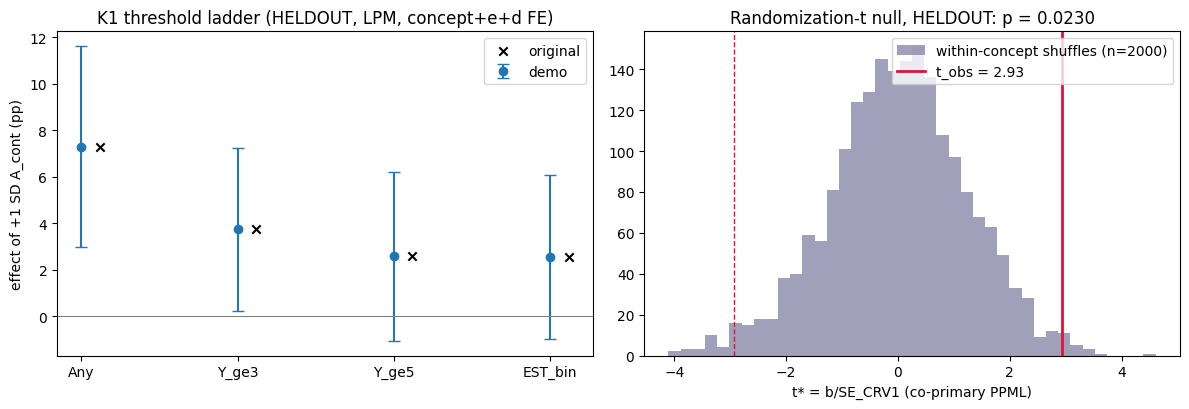

In [19]:
ref = data["reference_original_results"]
k1_rows = pd.read_csv(out / "k1_rows.csv")
ref_k1 = pd.DataFrame(ref["k1_rows_heldout"])

# ---- K1: demo vs original (held-out)
cmp = k1_rows[k1_rows.fold == "HELDOUT"][["test", "outcome", "unit", "estimate", "ci_lo", "ci_hi", "p_crv1", "N", "G"]].copy()
cmp = cmp.merge(ref_k1[["test", "outcome", "estimate", "ci_lo", "ci_hi"]].rename(
    columns={"estimate": "orig_estimate", "ci_lo": "orig_ci_lo", "ci_hi": "orig_ci_hi"}), on=["test", "outcome"], how="left")
pd.set_option("display.width", 200, "display.max_columns", 20)
print("=== K1 (HELDOUT fold): demo vs original ===")
print(cmp.round(4).to_string(index=False))

# ---- K1 verdict per the frozen decision rule (extensive = K1a-LPM IVW CI excludes 0; intensive = K1b IRR CI excludes 1)
iv = results["k1"]["ivw"] if "k1" in results else None
if iv:
    ext_ci = iv["K1a_LPM_pp_per_sd"]["ci"]
    int_ci = [math.exp(x) for x in iv["K1b_log_irr_per_sd"]["ci"]]
    ext, intens = ext_ci[0] > 0 or ext_ci[1] < 0, int_ci[0] > 1 or int_ci[1] < 1
    verdict = "BOTH" if ext and intens else "EXTENSIVE" if ext else "INTENSIVE-ONLY" if intens else "UNRESOLVED"
    d = results["k1"]["folds"]["HELDOUT"]
    print(f"\nK1 verdict (demo, HELDOUT only): {verdict}   [original, 3-fold IVW: BOTH]")
    print(f"  extensive LPM {iv['K1a_LPM_pp_per_sd']['est']:.2f} pp/SD CI [{ext_ci[0]:.2f}, {ext_ci[1]:.2f}];"
          f" intensive IRR/SD {math.exp(iv['K1b_log_irr_per_sd']['est']):.3f} CI [{int_ci[0]:.3f}, {int_ci[1]:.3f}]")
    print(f"  extensive share of log effect {d['ext_share']:.3f} (bootstrap CI {d['ci_ext_share']}, {d['draws_converged']} draws)")

# ---- K3
if "k3" in results:
    k3r = results["k3"]
    print("\n=== K3 (demo: HELDOUT only; original pools SCREEN+HELDOUT) ===")
    for g, v in k3r["groups"].items():
        print(f"  {g:14s} IRR/pooled SD {v['irr_per_pooled_sd']:.3f} CI [{v['ci'][0]:.3f}, {v['ci'][1]:.3f}]  G={v['G_group']}"
              f"{'  (descriptive only)' if v['descriptive_only'] else ''}")
    print(f"  Wald p_F {k3r['wald']['p_F']:.3f} (df {k3r['wald']['df']}), perm p {k3r['p_perm_wald']:.3f};"
          f" phys/rest ratio {k3r['contrast']['ratio']:.3f} CI {np.round(k3r['contrast']['ci'], 3).tolist()}, MDE80 {k3r['mde80_ratio']:.3f}")
    print("  original pooled K3:", ", ".join(f"{r['row']} {r['estimate']:.3f}" for r in ref["k3_rows_pooled"] if r["test"] == "K3_group"),
          "| Wald p", [round(r["p_crv1"], 3) for r in ref["k3_rows_pooled"] if r["test"] == "K3_wald_equality"][0])

# ---- INFERENCE
if "inference" in results:
    inf = pd.read_csv(out / "inference_rows.csv")
    ref_inf = pd.DataFrame(ref["inference_rows_heldout"]).rename(columns={"value": "orig_value"})
    ic = inf[inf.fold == "HELDOUT"][["test", "row", "value"]].merge(ref_inf[["test", "row", "orig_value"]], on=["test", "row"], how="left")
    print(f"\n=== INFERENCE (HELDOUT; demo draws {draws}, wild reps {wild}) vs original (2000 / 9999) ===")
    print(ic.round(4).to_string(index=False))

# ---- figure
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
lad = k1_rows[(k1_rows.test == "K1d_ladder") & (k1_rows.fold == "HELDOUT")]
x = np.arange(len(lad))
axs[0].errorbar(x, lad.estimate, yerr=[lad.estimate - lad.ci_lo, lad.ci_hi - lad.estimate], fmt="o", capsize=4, label="demo")
rl = ref_k1[ref_k1.test == "K1d_ladder"]
axs[0].scatter(x + 0.12, rl.estimate, marker="x", color="k", label="original")
axs[0].axhline(0, color="grey", lw=0.8)
axs[0].set_xticks(x, lad.outcome)
axs[0].set_ylabel("effect of +1 SD A_cont (pp)")
axs[0].set_title("K1 threshold ladder (HELDOUT, LPM, concept+e+d FE)")
axs[0].legend()
if "inference" in results:
    dd = pd.read_csv(out / "inference_draws.csv")
    t_obs = results["inference"]["rows"]["HELDOUT.coprimary_A_count"]["t_obs"]
    axs[1].hist(dd["HELDOUT_cnt_plain_t"].dropna(), bins=min(40, max(5, len(dd) // 5)), color="#88a", alpha=0.8,
                label=f"within-concept shuffles (n={len(dd)})")
    axs[1].axvline(t_obs, color="crimson", lw=2, label=f"t_obs = {t_obs:.2f}")
    axs[1].axvline(-t_obs, color="crimson", lw=1, ls="--")
    axs[1].set_xlabel("t* = b/SE_CRV1 (co-primary PPML)")
    axs[1].set_title(f"Randomization-t null, HELDOUT: p = {results['inference']['rows']['HELDOUT.coprimary_A_count']['p_rand_t']:.4f}")
    axs[1].legend()
plt.tight_layout()
plt.show()